# 02 — Estado del negocio y destinos

Este notebook responde a dos preguntas de negocio, usando la base ya limpia
(`/data/processed/civitatis.duckdb`, generada por `python -m src.limpieza`
y `python -m src.metricas`): **¿cómo va el negocio en conjunto?** (Sección A)
y **¿qué destinos funcionan mejor?** (Sección B).

Cada pregunta se responde con una consulta SQL por separado.

In [1]:
import sys
from pathlib import Path

sys.path.append(str(Path.cwd().parent))

import pandas as pd
import plotly.express as px

from src import conexion

con = conexion.connect_processed()
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 140)

## Sección A: Estado del negocio

### A1. Venta bruta vs. venta neta

Usamos la tabla `ventas` (ya agregada por día en `src/metricas.py`) para mostrar el total vendido en **todo el periodo cubierto por los datos** (acumulado, no un mes ni un año concreto — el rango exacto de fechas se muestra junto al resultado), distinguiendo entre:

- **Venta bruta**: la suma de `importe_eur` de todas las reservas, incluidas las canceladas.
- **Venta neta**: la misma suma, excluyendo las reservas con `estado = 'cancelada'` — es decir, lo que realmente se ha cobrado o se espera cobrar.

La diferencia entre ambas es el impacto económico directo de las cancelaciones, y se muestra tanto en euros como en porcentaje más abajo.

In [2]:
venta_total = con.execute('''
    SELECT
        sum(venta_bruta) AS venta_bruta,
        sum(venta_neta)  AS venta_neta
    FROM ventas
''').df()
venta_total

,venta_bruta,venta_neta
0,760568.3,651826.83


In [3]:
bruta = venta_total['venta_bruta'][0]
neta = venta_total['venta_neta'][0]
diferencia = bruta - neta
print(f"Venta bruta: {bruta:,.2f}")
print(f"Venta neta:  {neta:,.2f}")
print(f"Diferencia:  {diferencia:,.2f} ({100 * diferencia / bruta:.2f}% de la venta bruta)")

Venta bruta: 760,568.30
Venta neta:  651,826.83
Diferencia:  108,741.47 (14.30% de la venta bruta)


In [4]:
rango = con.execute('''
    SELECT
        min(fecha_reserva) AS fecha_desde,
        max(fecha_reserva) AS fecha_hasta,
        date_diff('day', min(fecha_reserva), max(fecha_reserva)) AS dias_totales
    FROM ventas
''').df()

fecha_desde = rango['fecha_desde'][0]
fecha_hasta = rango['fecha_hasta'][0]
dias = rango['dias_totales'][0]
anios = dias / 365.25

print(f"Periodo cubierto: {fecha_desde} a {fecha_hasta} ({dias} días, ~{anios:.1f} años)")

Periodo cubierto: 2023-04-19 00:00:00 a 2026-06-29 00:00:00 (1167 días, ~3.2 años)


**La diferencia entre venta bruta y venta neta son las reservas canceladas**: la
venta bruta cuenta *todas* las reservas (se cumplan o no), y la venta neta solo
las que de verdad se cobran (excluye las canceladas). La diferencia es de
108.741,47 € — un 14,30% de la venta bruta.

### A2. Evolución mensual de venta neta

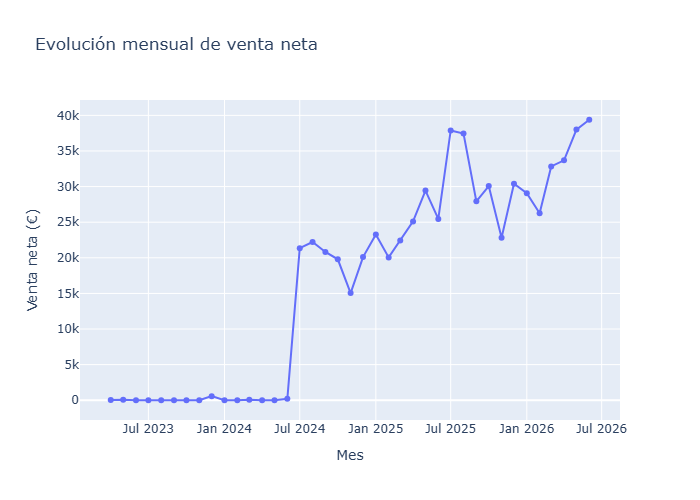

In [5]:
ventas_mensuales = con.execute('''
    WITH rango AS (
        SELECT
            date_trunc('month', min(fecha_reserva)) AS mes_min,
            date_trunc('month', max(fecha_reserva)) AS mes_max
        FROM ventas
    ),
    meses AS (
        SELECT unnest(generate_series(mes_min, mes_max, INTERVAL 1 MONTH)) AS mes
        FROM rango
    ),
    ventas_por_mes AS (
        SELECT
            date_trunc('month', fecha_reserva) AS mes,
            sum(venta_neta) AS venta_neta
        FROM ventas
        GROUP BY mes
    )
    SELECT
        m.mes,
        coalesce(v.venta_neta, 0) AS venta_neta
    FROM meses m
    LEFT JOIN ventas_por_mes v ON m.mes = v.mes
    ORDER BY m.mes
''').df()

fig = px.line(ventas_mensuales, x='mes', y='venta_neta', markers=True,
              title='Evolución mensual de venta neta',
              labels={'mes': 'Mes', 'venta_neta': 'Venta neta (€)'})
fig.show(renderer="png")

### Por qué la venta arranca en julio 2024

Antes de investigar la evolución, comprobamos si el salto de julio 2024 es un patrón de negocio real o un artefacto de los datos, cruzando 4 señales independientes.

In [6]:
# a) Reservas e importe medio, antes y después de julio 2024 — comprueba si el salto es de volumen o de precio
reservas_antes_despues = con.execute('''
    SELECT
        CASE WHEN fecha_reserva < '2024-07-01' THEN 'antes de julio 2024' ELSE 'desde julio 2024' END AS periodo,
        count(*) AS num_reservas,
        round(avg(importe_eur), 2) AS importe_medio_eur,
        round(sum(importe_eur) FILTER (WHERE estado != 'cancelada'), 2) AS venta_neta_total
    FROM reservas_limpias
    GROUP BY periodo
    ORDER BY periodo DESC
''').df()
reservas_antes_despues

,periodo,num_reservas,importe_medio_eur,venta_neta_total
0,desde julio 2024,8373,90.71,650886.22
1,antes de julio 2024,11,97.52,940.61


In [7]:
# b) Clientes nuevos por mes (fecha_alta) de junio 2023 a julio 2024 — comprueba si hay un salto correlacionado en registros
clientes_pre_julio2024 = con.execute('''
    SELECT
        date_trunc('month', fecha_alta) AS mes,
        count(*) AS clientes_nuevos
    FROM clientes_limpios
    WHERE fecha_alta >= '2023-06-01' AND fecha_alta < '2024-08-01'
    GROUP BY mes
    ORDER BY mes
''').df()
clientes_pre_julio2024

,mes,clientes_nuevos
0,2023-06-01,236
1,2023-07-01,240
2,2023-08-01,223
3,2023-09-01,230
4,2023-10-01,243
5,2023-11-01,224
6,2023-12-01,189
7,2024-01-01,243
8,2024-02-01,220
9,2024-03-01,236


In [8]:
# c) Tours distintos con reserva, antes y después de julio 2024, frente al catálogo total — comprueba si el catálogo creció en ese momento
tours_antes_despues = con.execute('''
    SELECT
        CASE WHEN fecha_reserva < '2024-07-01' THEN 'antes de julio 2024' ELSE 'desde julio 2024' END AS periodo,
        count(DISTINCT tour_id) AS tours_con_reserva,
        (SELECT count(*) FROM tours) AS catalogo_total
    FROM reservas_limpias
    GROUP BY periodo
    ORDER BY periodo DESC
''').df()
tours_antes_despues

,periodo,tours_con_reserva,catalogo_total
0,desde julio 2024,65,65
1,antes de julio 2024,10,65


In [9]:
# d) Fecha mínima de fecha_actividad y reservas con actividad anterior al 4 de julio de 2024 — la señal más directa: ¿hay algún tour realizado antes del arranque?
actividad_minima = con.execute('''
    SELECT
        min(fecha_actividad) AS fecha_actividad_minima,
        sum(CASE WHEN fecha_actividad < DATE '2024-07-04' THEN 1 ELSE 0 END) AS reservas_actividad_antes_4jul2024
    FROM reservas_limpias
''').df()
actividad_minima

,fecha_actividad_minima,reservas_actividad_antes_4jul2024
0,2024-07-04,0.0


In [10]:
# Venta media mensual: (a) sobre todo el periodo histórico, (b) solo desde julio 2024 (fase operativa, ver nota más abajo)
venta_media_mensual = con.execute('''
    SELECT
        round(avg(venta_neta_mes), 2) AS venta_media_mensual_periodo_completo,
        round(avg(venta_neta_mes) FILTER (WHERE mes >= '2024-07-01'), 2) AS venta_media_mensual_desde_julio_2024
    FROM (
        SELECT date_trunc('month', fecha_reserva) AS mes, coalesce(sum(venta_neta), 0) AS venta_neta_mes
        FROM ventas
        GROUP BY mes
    )
''').df()
venta_media_mensual

,venta_media_mensual_periodo_completo,venta_media_mensual_desde_julio_2024
0,21727.56,27120.26


La venta media mensual sobre **todo el periodo histórico** (30 meses con alguna venta, de los cuales solo 6 son anteriores a julio 2024 y casi vacíos) es de 21.727,56 €/mes — esta cifra **subestima** el ritmo real del negocio, porque diluye el promedio con esos meses sin apenas actividad. La venta media mensual **solo desde julio 2024** (24 meses, fase operativa) sube a 27.120,26 €/mes — esta es la cifra **más representativa** del ritmo de venta actual.

### Nota metodológica: por qué el gráfico de evolución "arranca" en julio 2024

Antes de julio de 2024, venta_neta es prácticamente 0€ (solo 11 reservas sueltas en 14 meses). Las 4 comprobaciones anteriores descartan que sea un artefacto de calidad de dato:

- El importe medio por reserva es idéntico antes y después (~85-100€) — descarta que sea un cambio de precios.
- Los clientes registrados crecen de forma estable desde junio 2023, sin ningún salto en julio 2024 — para esa fecha ya había ~3.000 clientes registrados. Descarta que sea "llegada repentina de usuarios".
- El catálogo completo de 65 tours y todos los proveedores ya existían antes de julio 2024. Descarta que sea "lanzamiento de nuevo catálogo".
- fecha_actividad (cuándo se realiza el tour) no tiene ningún valor anterior al 4 de julio de 2024, en ninguna reserva.

**Hipótesis**: julio de 2024 es la fecha de arranque operativo real del negocio de tours — las reservas con fecha anterior son casos aislados de clientes reservando con mucha antelación para actividades futuras, no el inicio de una fase de crecimiento gradual.

**Decisión**: no se eliminan esas 11 reservas (son datos válidos), pero se trata el periodo anterior a julio 2024 como fase pre-operativa al interpretar la evolución de ventas — el crecimiento real a analizar empieza en julio 2024, no antes.

### A3. Tasa de cancelación global

In [11]:
cancelacion = con.execute('''
    SELECT
        sum(CASE WHEN estado = 'cancelada' THEN 1 ELSE 0 END) AS reservas_canceladas,
        count(*) AS total_reservas,
        round(100.0 * sum(CASE WHEN estado = 'cancelada' THEN 1 ELSE 0 END) / count(*), 2) AS tasa_cancelacion_pct
    FROM reservas_limpias
''').df()
cancelacion

,reservas_canceladas,total_reservas,tasa_cancelacion_pct
0,1159.0,8384,13.82


**1 de cada 7 reservas se cancela.** Es justo lo que explica la diferencia
entre venta bruta y venta neta de A1: la venta bruta incluye reservas que
luego nunca se cobran.

### A3.1 Tasa de cancelación por canal y por destino

Descomponemos la tasa de cancelación global (13,82%) por canal y por
destino — mismo cálculo que arriba, pero con `GROUP BY` — para ver si el
problema está repartido de forma uniforme o concentrado en algún segmento
concreto. El destino se calcula a partir de la ciudad extraída
de la URL del tour (igual que en la Sección B).

In [12]:
cancelacion_canal = con.execute('''
    SELECT
        canal,
        round(100.0 * sum(CASE WHEN estado = 'cancelada' THEN 1 ELSE 0 END) / count(*), 2) AS tasa_cancelacion_pct,
        count(*) AS total_reservas
    FROM reservas_limpias
    GROUP BY canal
    ORDER BY tasa_cancelacion_pct DESC
''').df()
cancelacion_canal

,canal,tasa_cancelacion_pct,total_reservas
0,Afiliados,18.12,701
1,Social,16.81,815
2,SEO,13.34,2902
3,Directo,13.02,1444
4,SEM,12.85,1727
5,Email,12.33,795


In [13]:
cancelacion_destino = con.execute('''
    WITH tours_destino AS (
        SELECT tour_id, regexp_extract(url, 'civitatis\\.com/es/([^/]+)/', 1) AS destino
        FROM tours
    )
    SELECT
        td.destino,
        round(100.0 * sum(CASE WHEN r.estado = 'cancelada' THEN 1 ELSE 0 END) / count(*), 2) AS tasa_cancelacion_pct,
        count(*) AS total_reservas
    FROM reservas_limpias r
    JOIN tours_destino td ON r.tour_id = td.tour_id
    GROUP BY td.destino
    ORDER BY tasa_cancelacion_pct DESC
''').df()
cancelacion_destino

,destino,tasa_cancelacion_pct,total_reservas
0,paris,14.93,1005
1,madrid,14.93,1206
2,londres,14.71,836
3,estambul,14.46,484
4,marrakech,14.29,483
5,budapest,13.95,552
6,lisboa,13.90,518
7,nueva-york,13.68,731
8,praga,13.56,531
9,roma,12.36,1036


**La tasa de cancelación difiere en base al canal, pero no al destino:** 

`Afiliados` cancela un 18,12% de sus
reservas y `Social` un 16,81%, más de 3 y 2 puntos por encima,
respectivamente, de la media global (13,82%) — el resto de canales
(SEO 13,34%, Directo 13,02%, SEM 12,85%, Email 12,33%) está en línea con la
media o por debajo. 

Por destino no hay ningún caso destacable: todos se
mueven en una banda estrecha (11,50%–14,93%), a menos de 1,2 puntos de la
media global en el peor caso (París y Madrid, 14,93%).


Se podría revisar la calidad del
tráfico que traen `Afiliados` y `Social` — reservas que se cancelan más de
lo normal apuntan a una intención de compra más débil en esos canales
(tráfico impulsivo, ofertas poco claras, fricción en la comparación de
precios...) y son candidatos directos a optimizar.

## Sección B: Destinos

### B1. Ranking de los 10 destinos con más venta neta

`tours` y `proveedores` no tienen ninguna columna de "destino": lo único
disponible es la URL del tour (p. ej.
`.../es/roma/free-tour-por-roma/`), que sí trae la ciudad. Se comprobó si el
nombre de la empresa proveedora (`proveedores.nombre_empresa`) podía usarse
como nombre del destino, pero no — un mismo proveedor sirve tours de
ciudades distintas a las de su propio nombre, así que el destino real se
obtiene extrayendo la ciudad de la URL de `tours`, y no hace falta cruzar con
`proveedores`.

In [14]:
ranking_destinos = con.execute('''
    WITH tours_destino AS (
        SELECT tour_id, regexp_extract(url, 'civitatis\\.com/es/([^/]+)/', 1) AS destino
        FROM tours
    )
    SELECT
        td.destino,
        sum(r.importe_eur) AS venta_neta,
        min(r.fecha_reserva) AS primera_reserva,
        max(r.fecha_reserva) AS ultima_reserva
    FROM reservas_limpias r
    JOIN tours_destino td ON r.tour_id = td.tour_id
    WHERE r.estado != 'cancelada'
    GROUP BY td.destino
    ORDER BY venta_neta DESC
    LIMIT 10
''').df()
ranking_destinos

,destino,venta_neta,primera_reserva,ultima_reserva
0,paris,82713.96,2023-12-10 00:00:00,2026-06-28 05:12:11
1,madrid,76961.92,2023-04-19 00:00:00,2026-06-28 00:00:00
2,roma,76724.90,2024-07-01 21:34:00,2026-06-28 00:00:00
3,londres,76056.21,2023-12-12 00:00:00,2026-06-28 00:00:00
4,praga,53757.33,2024-07-02 10:01:34,2026-06-28 00:00:00
5,nueva-york,53707.42,2023-12-26 00:00:00,2026-06-29 00:38:16
6,lisboa,48933.87,2024-07-01 23:20:51,2026-06-28 10:50:45
7,estambul,46073.52,2024-07-02 10:43:09,2026-06-29 03:33:50
8,marrakech,45482.10,2024-07-01 21:52:53,2026-06-28 00:00:00
9,amsterdam,32558.09,2023-05-16 00:00:00,2026-06-28 00:00:00


In [15]:
fecha_maxima_dataset = con.execute('SELECT max(fecha_reserva) FROM reservas_limpias').fetchone()[0]

ranking_destinos = con.execute('''
    SELECT *, date_diff('day', primera_reserva, ?) AS antiguedad_dias
    FROM ranking_destinos
''', [fecha_maxima_dataset]).df()
ranking_destinos

,destino,venta_neta,primera_reserva,ultima_reserva,antiguedad_dias
0,paris,82713.96,2023-12-10 00:00:00,2026-06-28 05:12:11,932
1,madrid,76961.92,2023-04-19 00:00:00,2026-06-28 00:00:00,1167
2,roma,76724.90,2024-07-01 21:34:00,2026-06-28 00:00:00,728
3,londres,76056.21,2023-12-12 00:00:00,2026-06-28 00:00:00,930
4,praga,53757.33,2024-07-02 10:01:34,2026-06-28 00:00:00,727
5,nueva-york,53707.42,2023-12-26 00:00:00,2026-06-29 00:38:16,916
6,lisboa,48933.87,2024-07-01 23:20:51,2026-06-28 10:50:45,728
7,estambul,46073.52,2024-07-02 10:43:09,2026-06-29 03:33:50,727
8,marrakech,45482.10,2024-07-01 21:52:53,2026-06-28 00:00:00,728
9,amsterdam,32558.09,2023-05-16 00:00:00,2026-06-28 00:00:00,1140


### B2. % de clientes recurrentes en esos 10 destinos

Para cada destino, de todos los clientes que han comprado ahí (reservas no
canceladas), se muestra qué % son recurrentes según la tabla `clientes_recurrentes`
(2 o más reservas no canceladas, en cualquier destino).

In [16]:
destinos_top10 = tuple(ranking_destinos['destino'])

recurrencia_destinos = con.execute('''
    WITH tours_destino AS (
        SELECT tour_id, regexp_extract(url, 'civitatis\\.com/es/([^/]+)/', 1) AS destino
        FROM tours
    ),
    clientes_destino AS (
        SELECT DISTINCT td.destino, r.user_id
        FROM reservas_limpias r
        JOIN tours_destino td ON r.tour_id = td.tour_id
        WHERE r.estado != 'cancelada' AND td.destino IN ?
    )
    SELECT
        cd.destino,
        count(*) AS total_clientes,
        round(100.0 * sum(CASE WHEN cr.es_recurrente THEN 1 ELSE 0 END) / count(*), 2) AS pct_recurrencia,
        rd.antiguedad_dias
    FROM clientes_destino cd
    JOIN clientes_recurrentes cr ON cd.user_id = cr.user_id
    JOIN ranking_destinos rd ON cd.destino = rd.destino
    GROUP BY cd.destino, rd.antiguedad_dias
    ORDER BY pct_recurrencia DESC
''', [destinos_top10]).df()
recurrencia_destinos

,destino,total_clientes,pct_recurrencia,antiguedad_dias
0,roma,697,45.19,728
1,madrid,814,42.26,1167
2,lisboa,368,41.85,728
3,paris,693,40.55,932
4,amsterdam,359,38.44,1140
5,londres,590,37.12,930
6,praga,387,35.92,727
7,nueva-york,544,33.82,916
8,estambul,361,32.13,727
9,marrakech,374,27.81,728


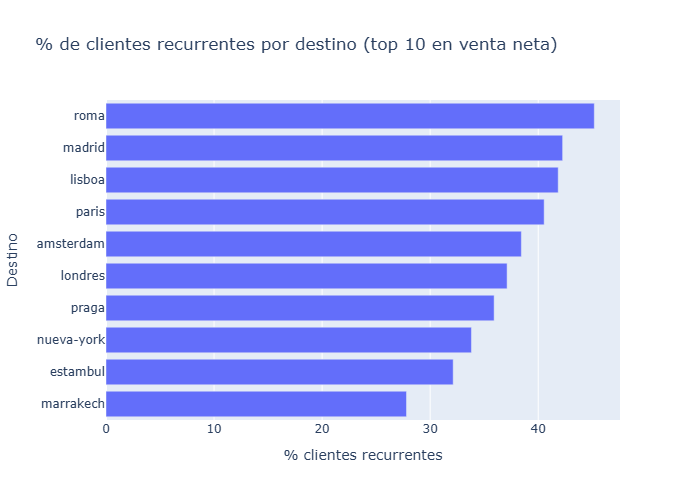

In [17]:
fig = px.bar(recurrencia_destinos.sort_values('pct_recurrencia'),
             x='pct_recurrencia', y='destino', orientation='h',
             title='% de clientes recurrentes por destino (top 10 en venta neta)',
             labels={'pct_recurrencia': '% clientes recurrentes', 'destino': 'Destino'})
fig.show(renderer="png")

**Nota sobre el análisis de destinos**: este análisis se hace sobre el
acumulado histórico completo, sin segmentar por periodo. Esto tiene una
limitación real: un destino reciente en el catálogo dispone de menos
tiempo para que sus clientes repitan, así que puede aparecer con una
retención aparentemente alta solo por no haber tenido tiempo suficiente
para que se observe lo contrario. Por eso se incluye la antigüedad de
cada destino (días desde su primera reserva) junto al ranking — al
revisar los resultados, se debe comprobar si los destinos con mayor
retención llevan poco tiempo activos antes de concluir que retienen mejor
de verdad.

Como próximo paso, convendría segmentar el análisis por antigüedad del
destino o por cohortes de fecha de primera reserva, para aislar este
efecto de forma más rigurosa.

### B3. Conclusión — quién vende mucho y quién fideliza

- **Vende mucho pero fideliza poco**: **París** es el destino nº1 en venta
  neta, pero solo el 4º en % de clientes recurrentes (40,55%). **Londres**
  pasa algo parecido: 4º en ventas, 6º en fidelización (37,12%). Son destinos
  que atraen mucho turista nuevo, pero no consiguen que vuelva a comprar en
  la misma proporción que otros.
- **Vende menos pero fideliza mucho**: **Lisboa** (7º en ventas) es el 3º
  destino con más % de recurrencia (41,85%), y **Ámsterdam** (el último de
  los 10 en ventas) es el 5º en fidelización (38,44%). Venden menos en
  volumen, pero el cliente que los prueba repite más que la media.
- **Roma y Madrid** son los únicos que están arriba en las dos cosas a la vez
  (top 3 en ventas y top 3 en fidelización).
- **Marrakech** es el caso opuesto: penúltimo en ventas y último en
  fidelización (27,81%).

## Conclusiones finales

1. **De cada 100€ que se reservan, casi 14,30€ se pierden por cancelaciones**
   (venta bruta 760.568,30 € frente a 651.826,83 € de venta neta real). Es el
   mismo problema que la tasa de cancelación: **1 de cada 7 reservas no llega
   a cobrarse**.
2. **La venta mensual crece de forma sostenida** desde mediados de 2024, sin
   caídas bruscas — el negocio no tiene un problema de demanda, tiene un
   problema de cancelaciones.
3. **Vender mucho y fidelizar mucho no siempre van juntos.** París y Londres
   traen más ingresos pero fidelizan peor que la media; Lisboa y Ámsterdam
   venden menos pero retienen mejor a quien los prueba. Antes de invertir más
   en atraer clientes nuevos a los destinos que más venden, merece la pena
   preguntarse por qué esos clientes no vuelven a comprar.
4. **La mayor retención de Roma, Madrid y Lisboa no se explica por ser
   destinos más nuevos.** Son los tres con más recurrencia (45,19%, 42,26% y
   41,85%) y tienen una antigüedad media de 874 días, prácticamente igual a
   la de los otros siete destinos del ranking (871 días de media, solo 3
   días de diferencia) — así que la limitación señalada en la Sección B (que
   un destino reciente puede parecer más fiel solo por falta de tiempo) no
   es la causa de esta diferencia de retención.